<a href="https://colab.research.google.com/github/Saiji/Data-Science-Work/blob/master/Predict_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===============================
# Kaggle Playground Series 2026 - Customer Churn
# Full Pipeline: EDA → Feature Engineering → LightGBM → Ensemble
# ===============================

# Install (if needed)
# !pip install lightgbm catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb

In [ ]:
# ===============================
# 1. Load Data
# ===============================
train = pd.read_csv('/kaggle/input/train.csv')
test = pd.read_csv('/kaggle/input/test.csv')
sample = pd.read_csv('/kaggle/input/sample_submission.csv')

TARGET = 'Churn'
ID = 'id'

(594194, 21) (254655, 20)
   id  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0   0    Male              0     Yes        Yes      29          Yes   
1   1    Male              0     Yes        Yes      58          Yes   
2   2    Male              0     Yes         No      58          Yes   
3   3  Female              0      No         No       1          Yes   
4   4  Female              0      No         No       1          Yes   

  MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0            No             DSL            Yes  ...              Yes   
1            No             DSL            Yes  ...               No   
2           Yes     Fiber optic             No  ...               No   
3            No     Fiber optic             No  ...               No   
4            No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0         Yes          No     

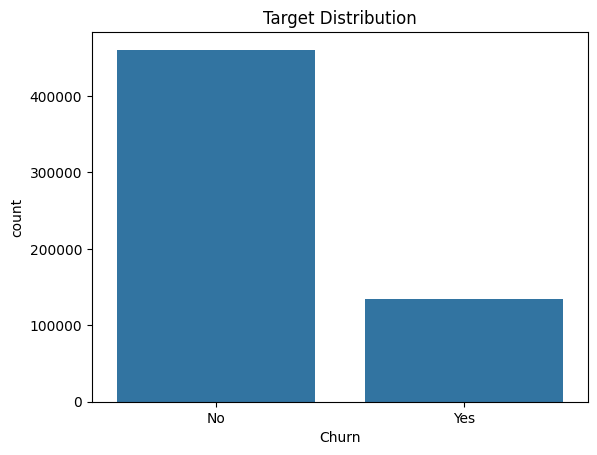

id                 0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
dtype: int64


In [3]:
# ===============================
# 2. Basic EDA
# ===============================
print(train.shape, test.shape)
print(train.head())

# Target distribution
sns.countplot(x=TARGET, data=train)
plt.title('Target Distribution')
plt.show()

# Missing values
missing = train.isnull().sum().sort_values(ascending=False)
print(missing.head(10))

In [4]:
# ===============================
# 3. Feature Engineering
# ===============================
train_test = pd.concat([train, test], axis=0).reset_index(drop=True)

# Identify categorical & numerical
cat_cols = train_test.select_dtypes(include=['object']).columns.tolist()
num_cols = train_test.select_dtypes(exclude=['object']).columns.tolist()
num_cols.remove(TARGET) if TARGET in num_cols else None

# Label Encoding
for col in cat_cols:
    le = LabelEncoder()
    train_test[col] = le.fit_transform(train_test[col].astype(str))

# Example interaction features
for col in num_cols[:3]:
    train_test[f'{col}_log'] = np.log1p(train_test[col])

# Split back
train_fe = train_test[~train_test[TARGET].isnull()]
test_fe = train_test[train_test[TARGET].isnull()]

X = train_fe.drop([TARGET, ID], axis=1)
y = train_fe[TARGET]
X_test = test_fe.drop([TARGET, ID], axis=1)

In [ ]:
# ===============================
# 4. Cross Validation + LightGBM
# ===============================

params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.03,
    'num_leaves': 64,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbosity': -1,
    'seed': 42
}

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof = np.zeros(len(X))
preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(folds.split(X, y)):
    print(f'Fold {fold}')

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**params, n_estimators=2000)

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
    )

    oof[val_idx] = model.predict_proba(X_val)[:, 1]
    preds += model.predict_proba(X_test)[:, 1] / folds.n_splits

auc = roc_auc_score(y, oof)
print('CV AUC:', auc)

# ===============================
# 5. Feature Importance
# ===============================
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importances.head(20))
